In [1]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [3]:
import medmnist
from medmnist import INFO, Evaluator

In [40]:
# Import local files
%load_ext autoreload
%autoreload 2
from bcnn_training import *
from cnn_training import get_semi_supervised_labels, SSLDataset
from plots import *
from variational_cnn import *
from constants import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
data_flag = 'dermamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [6]:
# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

BATCH_SIZE = 128

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [7]:
def default_setup(lr=0.001, l2_weight=0.0):
    model = VariationalCNN(n_channels, n_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_weight)
    return model, criterion, optimizer

In [8]:
RANDOM_SEED = 42

## Baseline 2: Bayesian CNN

#### 50% Unlabeled Rate

#### 75% Unlabeled Rate

In [10]:
# Create SSL versions of our datasets
unlabeled_rate = 0.75

train_labels_ssl_75 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_75 = SSLDataset(train_dataset, train_labels_ssl_75)
train_ssl_loader_75 = data.DataLoader(train_ssl_dataset_75, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.75 | Total examples: 7007 | Labeled examples: 1754 | Unlabeled examples: 5253
Class 0: 57/228 labeled, 171 unlabeled
Class 1: 90/359 labeled, 269 unlabeled
Class 2: 193/769 labeled, 576 unlabeled
Class 3: 20/80 labeled, 60 unlabeled
Class 4: 195/779 labeled, 584 unlabeled
Class 5: 1174/4693 labeled, 3519 unlabeled
Class 6: 25/99 labeled, 74 unlabeled


In [28]:
ssl_bmodel_75, criterion, optimizer = default_setup()
bcnn_history_75 = train_loop_bcnn_hard_pseudo_label(ssl_bmodel_75, train_ssl_loader_75, val_loader, criterion, optimizer, num_epochs=20, alpha=0.5, beta=2e-4, num_samples=10)

beta:0.0002


  0%|          | 0/55 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:01<00:00,  4.19it/s]


Epoch 1/20 | Train NLL: 3.8557 | Train KL (avg/batch): 1.5415 | Train Loss Unlabeled: 0.3330 | Val Loss: 1.3154 | Val AUC Macro: 0.4941 | Val AUC Global: 0.8462


100%|██████████| 8/8 [00:01<00:00,  4.13it/s]


...

Epoch 18/20 | Train NLL: 1.0836 | Train KL (avg/batch): 1.5391 | Train Loss Unlabeled: 0.2308 | Val Loss: 1.0417 | Val AUC Macro: 0.7288 | Val AUC Global: 0.9151


100%|██████████| 8/8 [00:02<00:00,  3.78it/s]


Epoch 19/20 | Train NLL: 1.0873 | Train KL (avg/batch): 1.5388 | Train Loss Unlabeled: 0.1906 | Val Loss: 1.0310 | Val AUC Macro: 0.7441 | Val AUC Global: 0.9168


100%|██████████| 8/8 [00:01<00:00,  4.06it/s]

Epoch 20/20 | Train NLL: 1.0631 | Train KL (avg/batch): 1.5386 | Train Loss Unlabeled: 0.2188 | Val Loss: 1.0253 | Val AUC Macro: 0.7286 | Val AUC Global: 0.9165


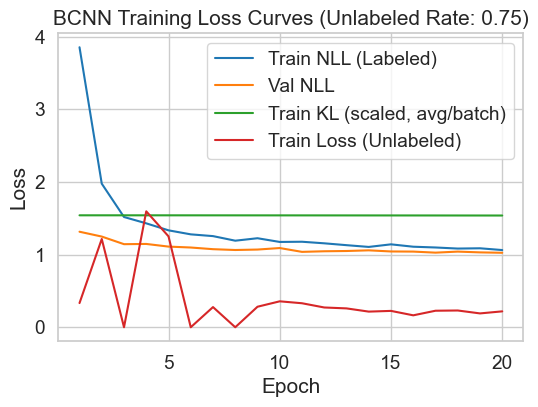

In [29]:
plot_loss_curves_bcnn(bcnn_history_75, unlabeled_rate=unlabeled_rate, use_unlabeled=True)

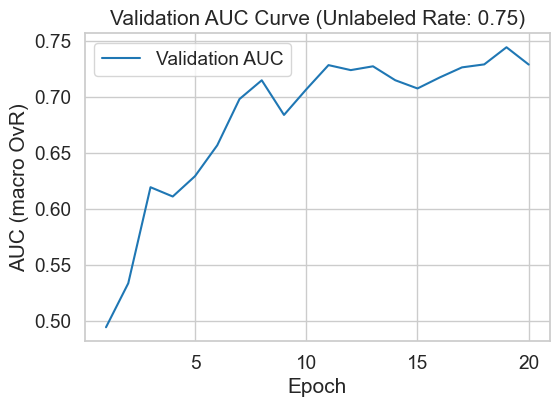

In [30]:
plot_auc_curve(bcnn_history_75, unlabeled_rate=unlabeled_rate)

In [31]:
best_bcnn_history_75 = max(bcnn_history_75, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_bcnn_history_75['epoch']} | Val AUC Macro: {best_bcnn_history_75['val_auc_macro']:.4f}")

best_bcnn_model_75 = VariationalCNN(n_channels, n_classes)
best_bcnn_model_75.load_state_dict(best_bcnn_history_75['model_state'])

Best Epoch: 19 | Val AUC Macro: 0.7441


<All keys matched successfully>

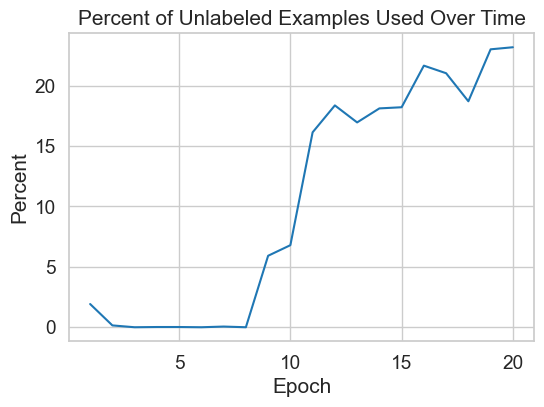

In [38]:
plot_percent_unlabeled_used(bcnn_history_75)

In [41]:
test_results_bcnn_75 = evaluate_bayesian(best_bcnn_model_75, test_loader, device='cpu')
test_results_bcnn_75

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:05<00:00,  1.45it/s]

preds: [5 5 5 ... 5 5 5]


{'macro_auc': 0.7331917623776391,
 'global_auc': 0.9152746769816936,
 'nll': np.float32(1.030442),
 'per_class_auc': [0.7229984215543782,
  0.7876073218788602,
  0.810855614973262,
  0.7140569473083841,
  0.6110104533123966,
  0.7992995471820166,
  0.6865140304341757],
 'confusion_matrix': array([[0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 1., 0.]])}

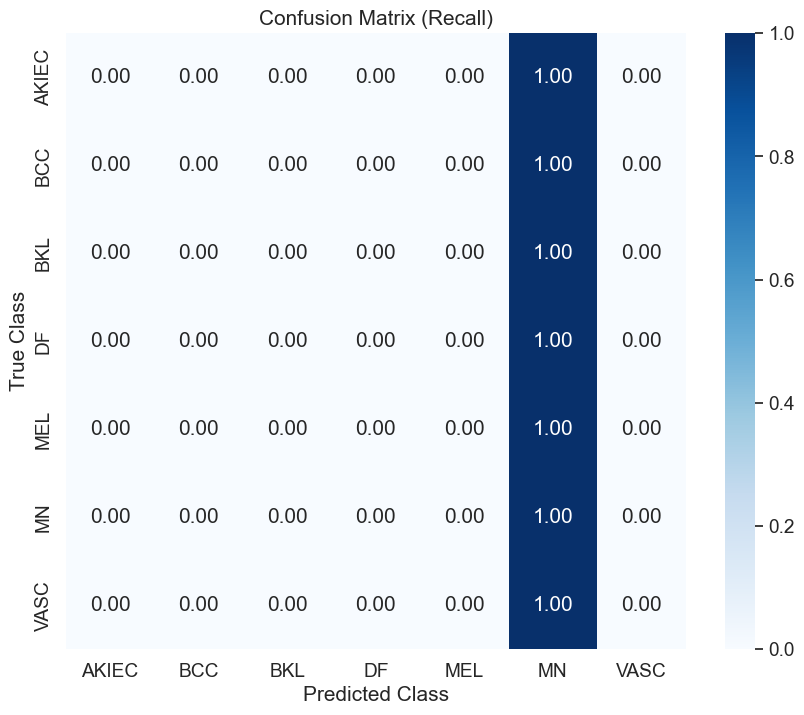

In [39]:
plot_per_class_recall(test_results_bcnn_75['confusion_matrix'], list(short_labels.values()))

In [47]:
with torch.no_grad():
    best_bcnn_model_75.eval()
    probs, targets = [], []
    for images, labels in tqdm(test_loader):
        images = images.to('cpu')
        mean_probs = best_bcnn_model_75.average_probs(images, num_samples=10)
        probs.append(mean_probs.cpu().numpy())
        targets.append(labels.squeeze().cpu().numpy())

probs = np.concatenate(probs)
targets = np.concatenate(targets)

100%|██████████| 8/8 [00:02<00:00,  2.83it/s]


In [49]:
preds = np.argmax(probs, axis=1)

In [50]:
print(f"Percentage of predictions that are class 5: {(preds == 5).mean() * 100:.1f}%")

Percentage of predictions that are class 5: 100.0%


#### 90% Unlabeled Rate